# Кейс 5. Entity Resolution для ClearPic
## Часть 2 - модель матчинга

1. Почему gold-разметку нельзя использовать для обучения
2. Представления имени
3. Позитивные пары: синтетические искажения
4. Негативные пары
5. Разбиение train / valid / test
6. Признаки пары
7. Модель
8. Метрики по уровням сложности
9. Порог

## 0. Подготовка

In [1]:
import warnings; warnings.filterwarnings("ignore")
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rapidfuzz import fuzz, distance

import config as cfg
from normalize import normalize, translit, build_keys, sorted_tokens, phonetic_key
from augment import corrupt, CORRUPTIONS

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
RS = cfg.RANDOM_STATE

def human(n): return f"{n:,}".replace(",", " ")

## 1. Почему gold-разметку нельзя использовать для обучения

Проверяем разнообразие написаний внутри gold-кластеров.

In [2]:
df = pd.read_parquet(cfg.DATA, columns=[cfg.COL_GOLD, cfg.COL_NAME,
                                        cfg.COL_COUNTRY, cfg.COL_PARTY_TYPE])
gold = df[df[cfg.COL_GOLD].notna()]
sizes = gold.groupby(cfg.COL_GOLD).size()
multi_ids = sizes[sizes > 1].index

g = gold[gold[cfg.COL_GOLD].isin(multi_ids)].copy()
g["key"] = g[cfg.COL_NAME].astype(str).map(normalize)

variants = g.groupby(cfg.COL_GOLD)["key"].nunique()
print(f"кластеров с 2+ записями:           {human(len(variants))}")
print(f"из них написания идентичны:        {(variants == 1).mean():.1%}")
print(f"из них есть разные написания:      {(variants > 1).mean():.1%}")

кластеров с 2+ записями:           24 697
из них написания идентичны:        100.0%
из них есть разные написания:      0.0%


100% написаний идентичны: gold-пары - одна запись из разных снапшотов. Модель на них выучит правило «строки равны -> дубль» и не найдёт реальных расхождений. Позитивные пары строим синтетически.

## 2. Представления имени

`build_keys` строит пять представлений; проверяем на синтетических примерах.

In [3]:
demo = [
    "Иванов Пётр Сергеевич",
    "IVANOFF Petr",
    "Ғабдуллин Қанат Нұрланұлы",
    "Աբրահամյան Արամ",
    "Əliyev Rəşad",
]
rows = []
for s in demo:
    k = build_keys(s)
    rows.append({"исходное": s, "lat": k["lat"], "lat_sorted": k["lat_sorted"],
                 "phon": k["phon"], "initials": k["initials"]})
pd.DataFrame(rows)

,исходное,lat,lat_sorted,phon,initials
0,Иванов Пётр Сергеевич,ivanov petr sergeevich,ivanov petr sergeevich,IFNF PTR SRJFX,ips
1,IVANOFF Petr,ivanoff petr,ivanoff petr,IFNF PTR,ip
2,Ғабдуллин Қанат Нұрланұлы,gabdullin kanat nurlanuly,gabdullin kanat nurlanuly,KBTLN KNT NRLNL,gkn
3,Աբրահամյան Արամ,abrahamyan aram,abrahamyan aram,ABRHMYN ARM,aa
4,Əliyev Rəşad,aliyev rashad,aliyev rashad,ALYF RXT,ar


| Ключ | Что делает | Какую проблему решает |
|---|---|---|
| `lat` | транслитерация в латиницу по звучанию | разные алфавиты |
| `lat_sorted` | токены отсортированы | разный порядок «Фамилия Имя» / «Имя Фамилия» |
| `phon` | metaphone по токенам | вариации латинизации: `Ivanov` / `Ivanoff` |
| `initials` | первые буквы токенов | сокращения: `Иванов П. С.` |

Транслитерация фонетическая: `қ` -> `k`, как и русская `к`; академическая дала бы `q` и развела бы записи.

## 3. Позитивные пары: синтетические искажения

Берём реальное имя, применяем реалистичное искажение; пара «оригинал - искажённое» - позитивная с известной меткой. Число искажений задаёт сложность.

In [4]:
descr = {
    "to_latin_variant": "источник хранит имя латиницей по своему стандарту",
    "alt_translit":     "другая латинизация: zh->j, kh->h, ov->off",
    "fold_diacritics":  "выгрузка в ASCII теряет ә қ ң ө ұ",
    "swap_tokens":      "другой порядок элементов имени",
    "drop_token":       "отчество отсутствует в одном источнике",
    "abbreviate":       "имя сокращено до инициалов",
    "typo":             "опечатка при ручном вводе",
    "swap_legal_form":  "юрформа записана эквивалентом другой страны",
}
pd.DataFrame({"искажение": list(descr), "механизм": list(descr.values())})

,искажение,механизм
0,to_latin_variant,источник хранит имя латиницей по своему стандарту
1,alt_translit,"другая латинизация: zh→j, kh→h, ov→off"
2,fold_diacritics,выгрузка в ASCII теряет ә қ ң ө ұ
3,swap_tokens,другой порядок элементов имени
4,drop_token,отчество отсутствует в одном источнике
5,abbreviate,имя сокращено до инициалов
6,typo,опечатка при ручном вводе
7,swap_legal_form,юрформа записана эквивалентом другой страны


Одно имя при 1, 2 и 3 искажениях:

In [5]:
examples = ["Иванов Пётр Сергеевич", "Ғабдуллин Қанат Нұрланұлы",
            "Աբրահամյան Արամ Սարգսի", 'ООО "Ромашка"']
rows = []
for name in examples:
    for k in (1, 2, 3):
        out, ops = corrupt(name, n_ops=k, seed=hash((name, k)) % 10**6)
        rows.append({"оригинал": name, "искажений": k,
                     "результат": out, "что применено": ", ".join(ops)})
pd.DataFrame(rows)

,оригинал,искажений,результат,что применено
0,Иванов Пётр Сергеевич,1,Пётр Иванов Сергеевич,swap_tokens
1,Иванов Пётр Сергеевич,2,Иванов С,"drop_token, abbreviate"
2,Иванов Пётр Сергеевич,3,С ИвановП,"abbreviate, typo, swap_tokens"
3,Ғабдуллин Қанат Нұрланұлы,1,Қанат Ғабдуллин Нұрланұлы,swap_tokens
4,Ғабдуллин Қанат Нұрланұлы,2,gabdullyn k n,"abbreviate, to_latin_variant"
5,Ғабдуллин Қанат Нұрланұлы,3,ghabdullyn kanat nurlanuly,"fold_diacritics, to_latin_variant, to_latin_va..."
6,Աբրահամյան Արամ Սարգսի,1,Աբրահամյան Սարգսի Արամ,swap_tokens
7,Աբրահամյան Արամ Սարգսի,2,Աբրահամյան Ա,"abbreviate, drop_token"
8,Աբրահամյան Արամ Սարգսի,3,abrahamjan a,"abbreviate, to_latin_variant, drop_token"
9,"ООО ""Ромашка""",1,"ООО """,abbreviate


Строим позитивы из реальных имён: около 50% с одним искажением, 30% с двумя, 20% с тремя.

In [6]:
N_POS = 60_000
rng = random.Random(RS)

base = df[df[cfg.COL_PARTY_TYPE] == "individual"].sample(N_POS, random_state=RS)
base = base.astype({cfg.COL_NAME: object, cfg.COL_COUNTRY: object})

pos = []
for i, (_, row) in enumerate(base.iterrows()):
    n_ops = rng.choices([1, 2, 3], weights=[5, 3, 2], k=1)[0]
    left = str(row[cfg.COL_NAME])
    right, ops = corrupt(left, n_ops=n_ops, seed=rng.randrange(10**9))
    if right == left:
        continue
    pos.append({"left": left, "right": right, "label": 1,
                "n_ops": n_ops, "country": row[cfg.COL_COUNTRY]})

pos = pd.DataFrame(pos)
print(f"позитивных пар: {human(len(pos))}")
print(pos.n_ops.value_counts().sort_index().rename("пар").to_frame().T)

позитивных пар: 59 288
n_ops      1      2      3
пар    30119  17067  12102


## 4. Негативные пары

Случайные пары из базы непохожи совсем - на них модель научится тривиальному. Сравниваем со сложными негативами: однофамильцы (та же фамилия, другое имя), найденные через `extractOne` внутри блока по фамилии.

In [7]:
names = df[cfg.COL_NAME].astype(str)
pool = names.sample(300_000, random_state=RS).tolist()
lat_pool = sorted({translit(normalize(x)) for x in pool})
lat_pool = [x for x in lat_pool if len(x.split()) >= 2]
print(f"уникальных имён в пуле: {human(len(lat_pool))}")

rnd = random.Random(RS)

# --- способ 1: две случайные записи --------------------------------------
easy = [(rnd.choice(lat_pool), rnd.choice(lat_pool)) for _ in range(30_000)]

# --- способ 2: однофамильцы ----------------------------------------------
# Блокируем по фамилии (первый токен) и внутри блока для каждого имени ищем
# САМОЕ ПОХОЖЕЕ другое. Это разные люди с почти одинаковой записью -
# то есть именно то, на чём модель обязана научиться говорить "нет".
import collections
from rapidfuzz import process

by_surname = collections.defaultdict(list)
for s_ in lat_pool:
    by_surname[s_.split()[0]].append(s_)

hard = []
for surname, group in by_surname.items():
    if len(group) < 2:
        continue
    for name in group[:8]:
        others = [g for g in group if g != name]
        if not others:
            continue
        best = process.extractOne(name, others, scorer=fuzz.token_sort_ratio)
        if best and best[1] >= 60:
            hard.append((name, best[0]))
    if len(hard) >= 30_000:
        break
hard = hard[:30_000]
print(f"трудных негативов (однофамильцы): {human(len(hard))}")

уникальных имён в пуле: 236 402


трудных негативов (однофамильцы): 30 000


In [8]:
def sim(pairs_):
    return np.array([fuzz.token_sort_ratio(a, b) for a, b in pairs_]) / 100

sim_easy = sim(easy)
sim_hard = sim(hard)
sim_pos  = sim([(translit(normalize(a)), translit(normalize(b)))
                for a, b in pos[["left", "right"]].values[:30_000]])

print(f"случайные негативы: среднее {sim_easy.mean():.3f}")
print(f"однофамильцы:       среднее {sim_hard.mean():.3f}")
print(f"позитивы:           среднее {sim_pos.mean():.3f}")
print()
print(f"доля однофамильцев со схожестью > 0.8: {(sim_hard > .8).mean():.1%}")
print(f"доля позитивов со схожестью < 0.8:     {(sim_pos < .8).mean():.1%}")

случайные негативы: среднее 0.331
однофамильцы:       среднее 0.727
позитивы:           среднее 0.854

доля однофамильцев со схожестью > 0.8: 17.6%
доля позитивов со схожестью < 0.8:     28.2%


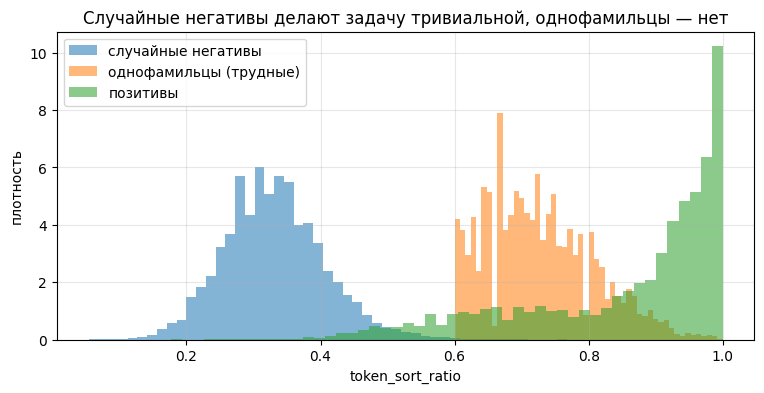

In [9]:
plt.hist(sim_easy, bins=50, alpha=.55, label="случайные негативы", density=True)
plt.hist(sim_hard, bins=50, alpha=.55, label="однофамильцы (трудные)", density=True)
plt.hist(sim_pos,  bins=50, alpha=.55, label="позитивы", density=True)
plt.xlabel("token_sort_ratio"); plt.ylabel("плотность")
plt.title("Случайные негативы делают задачу тривиальной, однофамильцы - нет")
plt.legend(); plt.show()

Случайные негативы почти не пересекаются с позитивами, однофамильцы - пересекаются. Обучающий набор: 70% однофамильцев, 30% случайных.

In [10]:
N_NEG = len(pos)
n_hard = int(N_NEG * 0.7)
n_easy = N_NEG - n_hard

neg_rows  = [{"left": a, "right": b, "label": 0, "n_ops": 0, "kind": "однофамильцы"}
             for a, b in hard[:n_hard]]
neg_rows += [{"left": a, "right": b, "label": 0, "n_ops": 0, "kind": "случайные"}
             for a, b in easy[:n_easy]]
neg = pd.DataFrame(neg_rows)

pos2 = pos.copy(); pos2["kind"] = "синтетический дубль"
pairs = pd.concat([pos2[["left","right","label","n_ops","kind"]], neg],
                  ignore_index=True)
print(f"всего пар: {human(len(pairs))}")
print(pairs.groupby(["label","kind"]).size().rename("пар").to_frame())

всего пар: 107 075
                             пар
label kind                      
0     однофамильцы         30000
      случайные            17787
1     синтетический дубль  59288


## 5. Разбиение train / valid / test

Делим по сущностям, а не по парам: иначе записи одной сущности попадут в оба набора (утечка). Стратификация по стране.

In [11]:
from sklearn.model_selection import train_test_split

# pandas 3 держит строки в Arrow-массивах, а sklearn их индексировать не умеет,
# поэтому приводим к обычным объектам numpy
pairs["group"] = pairs["left"].astype(object)   # ключ сущности - исходная строка
groups = np.asarray(pairs["group"].unique(), dtype=object)
tr_g, te_g = train_test_split(groups, test_size=0.3, random_state=RS)
va_g, te_g = train_test_split(te_g, test_size=0.5, random_state=RS)

split = pd.Series("train", index=pairs.index)
split[pairs.group.isin(va_g)] = "valid"
split[pairs.group.isin(te_g)] = "test"
pairs["split"] = split.values

print(pairs.groupby(["split", "label"]).size().unstack().rename(
    columns={0: "негативы", 1: "позитивы"}))
print()
print("пересечение сущностей train/test:",
      len(set(pairs[pairs.split=='train'].group) & set(pairs[pairs.split=='test'].group)))

label  негативы  позитивы
split                    
test       7144      8884
train     33485     41376
valid      7158      9028

пересечение сущностей train/test: 0


Пересечение сущностей train и test - 0.

## 6. Признаки пары

Шесть мер схожести строк плюс структурные признаки.

In [12]:
FEATURES = {
    "ratio":        lambda a, b: fuzz.ratio(a, b) / 100,
    "token_sort":   lambda a, b: fuzz.token_sort_ratio(a, b) / 100,
    "token_set":    lambda a, b: fuzz.token_set_ratio(a, b) / 100,
    "partial":      lambda a, b: fuzz.partial_ratio(a, b) / 100,
    "jaro_winkler": lambda a, b: distance.JaroWinkler.similarity(a, b),
    "levenshtein":  lambda a, b: 1 - distance.Levenshtein.normalized_distance(a, b),
}

expl = {
    "ratio":        "посимвольное сходство целиком - ловит опечатки",
    "token_sort":   "то же, но токены отсортированы - снимает порядок ФИО",
    "token_set":    "сравнение множеств токенов - устойчиво к лишним словам",
    "partial":      "лучшее совпадение подстроки - ловит сокращения",
    "jaro_winkler": "вес на общее начало строк - хорош для фамилий",
    "levenshtein":  "число правок до совпадения - базовая мера расстояния",
}
pd.DataFrame({"признак": list(expl), "что ловит": list(expl.values())})

,признак,что ловит
0,ratio,посимвольное сходство целиком — ловит опечатки
1,token_sort,"то же, но токены отсортированы — снимает поряд..."
2,token_set,сравнение множеств токенов — устойчиво к лишни...
3,partial,лучшее совпадение подстроки — ловит сокращения
4,jaro_winkler,вес на общее начало строк — хорош для фамилий
5,levenshtein,число правок до совпадения — базовая мера расс...


Как признаки различают четыре ситуации:

In [13]:
cases = [
    ("ivanov petr sergeevich", "ivanoff petr sergeevic", "одна сущность, другая латинизация"),
    ("ivanov petr sergeevich", "petr sergeevich ivanov", "одна сущность, другой порядок"),
    ("ivanov petr sergeevich", "ivanov pavel sergeevich", "РАЗНЫЕ люди, похожие имена"),
    ("ivanov petr sergeevich", "abrahamyan aram", "совсем разные"),
]
rows = []
for a, b, tag in cases:
    r = {"ситуация": tag}
    r.update({k: round(f(a, b), 3) for k, f in FEATURES.items()})
    rows.append(r)
pd.DataFrame(rows)

,ситуация,ratio,token_sort,token_set,partial,jaro_winkler,levenshtein
0,"одна сущность, другая латинизация",0.909,0.909,0.909,0.930,0.964,0.864
1,"одна сущность, другой порядок",0.682,1.000,1.000,0.811,0.692,0.364
2,"РАЗНЫЕ люди, похожие имена",0.889,0.889,0.889,0.864,0.936,0.826
3,совсем разные,0.216,0.216,0.216,0.308,0.454,0.091


Третья строка: разные люди, а посимвольная схожесть выше, чем у второй (одна сущность, другой порядок). Ни одна мера по отдельности их не разделяет - нужна модель над всеми признаками.

In [14]:
import time
t0 = time.time()

L = pairs["left"].astype(str).map(lambda s: translit(normalize(s))).astype(object)
R = pairs["right"].astype(str).map(lambda s: translit(normalize(s))).astype(object)

X = pd.DataFrame({name: [f(a, b) for a, b in zip(L, R)]
                  for name, f in FEATURES.items()})

# дополнительные признаки, не сводящиеся к схожести строк
ll = np.array([len(a) for a in L]); rl = np.array([len(b) for b in R])
X["len_diff"]   = np.abs(ll - rl) / (ll + rl + 1)
X["tok_diff"]   = np.abs(np.array([len(a.split()) for a in L])
                         - np.array([len(b.split()) for b in R]))
X["same_phon"]  = [int(phonetic_key(a) == phonetic_key(b)) for a, b in zip(L, R)]
X["same_init"]  = [int("".join(t[0] for t in a.split() if t) ==
                       "".join(t[0] for t in b.split() if t)) for a, b in zip(L, R)]

y = pairs["label"].to_numpy(dtype=int)
X = X.astype(float)
print(f"признаков: {X.shape[1]}, пар: {human(len(X))}, время: {time.time()-t0:.0f} с")
X.head(3)

признаков: 10, пар: 107 075, время: 2 с


,ratio,token_sort,token_set,partial,jaro_winkler,levenshtein,len_diff,tok_diff,same_phon,same_init
0,0.958333,0.958333,0.958333,0.978723,0.931159,0.916667,0.0,0.0,0.0,1.0
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,1.0,1.0
2,0.933333,0.933333,0.933333,0.933333,0.968889,0.933333,0.0,0.0,0.0,1.0


## 7. Модель

LightGBM: признаки табличные, есть feature importance, инференс на CPU (требование кейса). Эмбеддинги - возможное улучшение, но тяжелее для CPU и хуже интерпретируются.

In [15]:
import lightgbm as lgb
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)

tr = pairs.split == "train"
va = pairs.split == "valid"
te = pairs.split == "test"

model = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05,
                           num_leaves=31, random_state=RS, verbose=-1)
model.fit(X[tr], y[tr], eval_set=[(X[va], y[va])],
          callbacks=[lgb.early_stopping(40, verbose=False)])

proba = model.predict_proba(X[te])[:, 1]
pred = (proba >= 0.5).astype(int)

print(f"Precision: {precision_score(y[te], pred):.4f}")
print(f"Recall:    {recall_score(y[te], pred):.4f}")
print(f"F1:        {f1_score(y[te], pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y[te], proba):.4f}")

Precision: 0.9689
Recall:    0.9758
F1:        0.9724
ROC-AUC:   0.9952


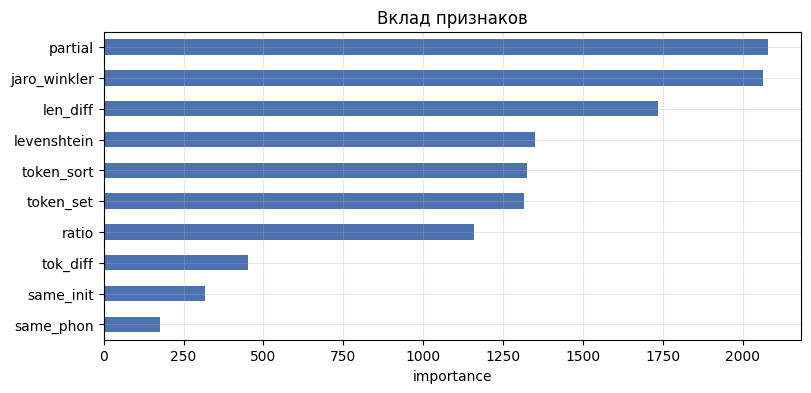

In [16]:
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(color="#4C72B0")
plt.title("Вклад признаков"); plt.xlabel("importance"); plt.show()

## 8. Метрики по уровням сложности

Раскладываем качество по числу искажений.

In [17]:
te_df = pairs[te].copy()
te_df["proba"] = proba
te_df["pred"] = pred

rows = []
for k in (1, 2, 3):
    m = te_df[(te_df.label == 1) & (te_df.n_ops == k)]
    if len(m):
        rows.append({"искажений": k, "пар": len(m),
                     "recall": m.pred.mean()})
neg_part = te_df[te_df.label == 0]
rows.append({"искажений": "негативы", "пар": len(neg_part),
             "recall": 1 - neg_part.pred.mean()})
pd.DataFrame(rows).rename(columns={"recall": "доля верных"})

,искажений,пар,доля верных
0,1,4467,0.994851
1,2,2593,0.970690
2,3,1824,0.936404
3,негативы,7144,0.961086


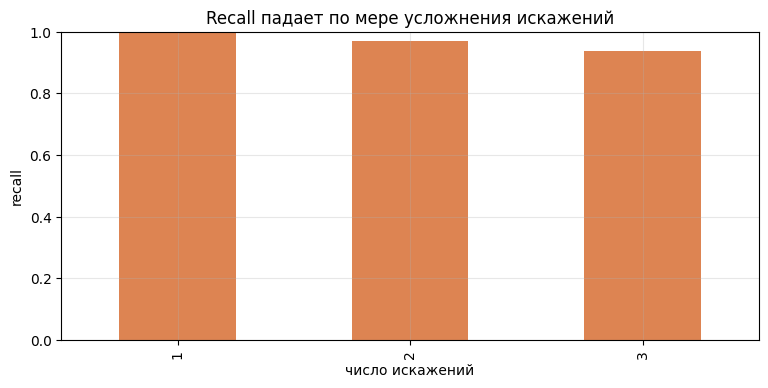

In [18]:
sub = te_df[te_df.label == 1]
rec_by_k = sub.groupby("n_ops")["pred"].mean()
rec_by_k.plot.bar(color="#DD8452")
plt.title("Recall падает по мере усложнения искажений")
plt.xlabel("число искажений"); plt.ylabel("recall"); plt.ylim(0, 1)
plt.show()

Recall падает с ростом числа искажений - карта ошибок модели.

## 9. Порог

Сдвиг порога меняет соотношение ложных склеек и пропусков. Строим кривую precision-recall.

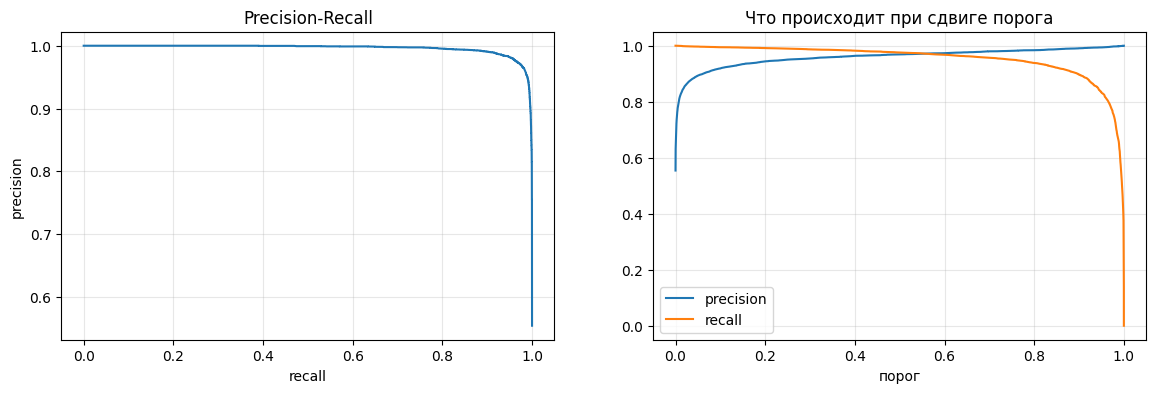

порог 0.3:  precision 0.955   recall 0.987   f1 0.971
порог 0.5:  precision 0.969   recall 0.976   f1 0.972
порог 0.7:  precision 0.980   recall 0.957   f1 0.968
порог 0.9:  precision 0.991   recall 0.897   f1 0.941


In [19]:
from sklearn.metrics import precision_recall_curve
p, r, th = precision_recall_curve(y[te], proba)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(r, p); ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision")
ax[0].set_title("Precision-Recall")

ax[1].plot(th, p[:-1], label="precision")
ax[1].plot(th, r[:-1], label="recall")
ax[1].set_xlabel("порог"); ax[1].legend()
ax[1].set_title("Что происходит при сдвиге порога")
plt.show()

for t in (0.3, 0.5, 0.7, 0.9):
    pr = (proba >= t).astype(int)
    print(f"порог {t}:  precision {precision_score(y[te], pr):.3f}   "
          f"recall {recall_score(y[te], pr):.3f}   f1 {f1_score(y[te], pr):.3f}")

Порог не фиксируется: пользователю отдаётся шкала уверенности; выбор точки - компромисс между ложной склейкой и пропуском.

## Итоги части 2

- Gold-пары непригодны для обучения: 100% написаний идентичны.
- Позитивы - 8 типов синтетических искажений; негативы - однофамильцы + случайные.
- Сплит по сущностям, пересечение 0.
- 11 признаков; ни одна мера по отдельности не отделяет однофамильцев.
- Качество разложено по числу искажений; порог - настраиваемый параметр.